# 02 · Exploratory Data Analysis
**Project**: War Shocks & Global Financial Risk Spillover  
**Input**: `data/processed/` — outputs from `01_data_collection.ipynb`  
**Output**: `outputs/figures/fig1–fig5b`, `outputs/tables/table_adf_tests`, `table_war_vs_calm`

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from src.data_loader import DATA_RAW_DIR, DATA_PROC_DIR
from src.eda import (
    plot_volatility_timeseries,
    plot_return_distributions,
    plot_correlation_heatmaps,
    plot_event_windows,
    plot_macro_war_linkage,
    run_adf_tests,
    war_vs_calm_stats,
    plot_crisis_decomposition,
)

END = "2025-12-31"

## 1  Load Processed Data

In [ ]:
combined   = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",  index_col=0, parse_dates=True)
returns_df = pd.read_excel(f"{DATA_PROC_DIR}/log_returns.xlsx",             index_col=0, parse_dates=True)
vol_df     = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",      index_col=0, parse_dates=True)
war_dummy  = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",             index_col=0, parse_dates=True)
events     = pd.read_excel(f"{DATA_RAW_DIR}/war_events.xlsx",  parse_dates=["start_date", "end_date"])

print(f"combined   : {combined.shape}")
print(f"returns_df : {returns_df.shape}")
print(f"vol_df     : {vol_df.shape}")
print(f"war_dummy  : {war_dummy.shape}")
print(f"war_dummy columns : {list(war_dummy.columns)}")
print(f"events     : {len(events)} war events loaded")
events[["event_name", "start_date", "end_date", "intensity"]]

required = ["mideast_war", "high_intensity", "gfc_crisis", "covid_crisis", "any_crisis"]
print()
print(war_dummy[required].sum().rename("days_active").to_frame())

combined   : (5030, 16)
returns_df : (5030, 16)
vol_df     : (5030, 8)
war_dummy  : (5030, 5)
war_dummy columns : ['mideast_war', 'high_intensity', 'gfc_crisis', 'covid_crisis', 'any_crisis']
events     : 7 war events loaded


                days_active
mideast_war            3760
high_intensity          597
gfc_crisis              209
covid_crisis            168
any_crisis              377


---
## 2  Fig 1 · Rolling Volatility + War Events

**Attention**: Volatility spikes coinciding with war shading.  
Note the two dominant spikes: GFC (2008-09) and COVID (2020) — far larger than any Middle East event alone, which motivates the four-regime crisis control in Table 2.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig1_volatility_timeseries.png


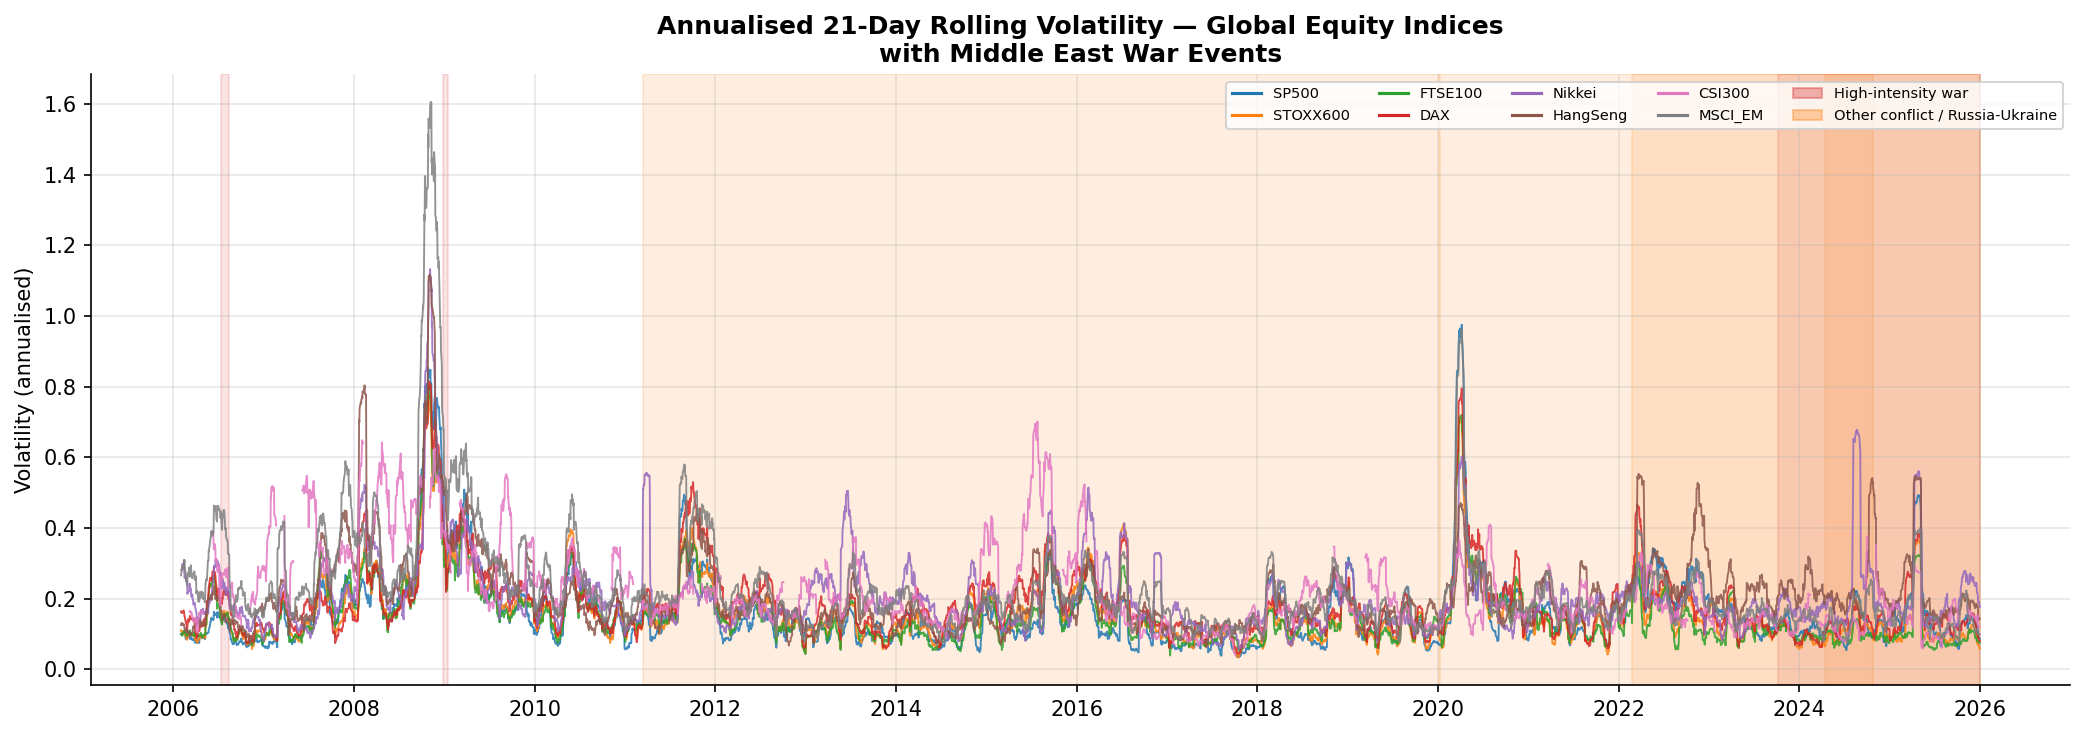

In [3]:
plot_volatility_timeseries(vol_df, events, end_date=END)

---
## 3  Fig 2 · Return Distributions vs Normal

**Attention**: Excess kurtosis > 0 in **all** markets → fat tails → linear VAR is mis-specified → LSTM/GRU justified.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig2_return_distributions.png


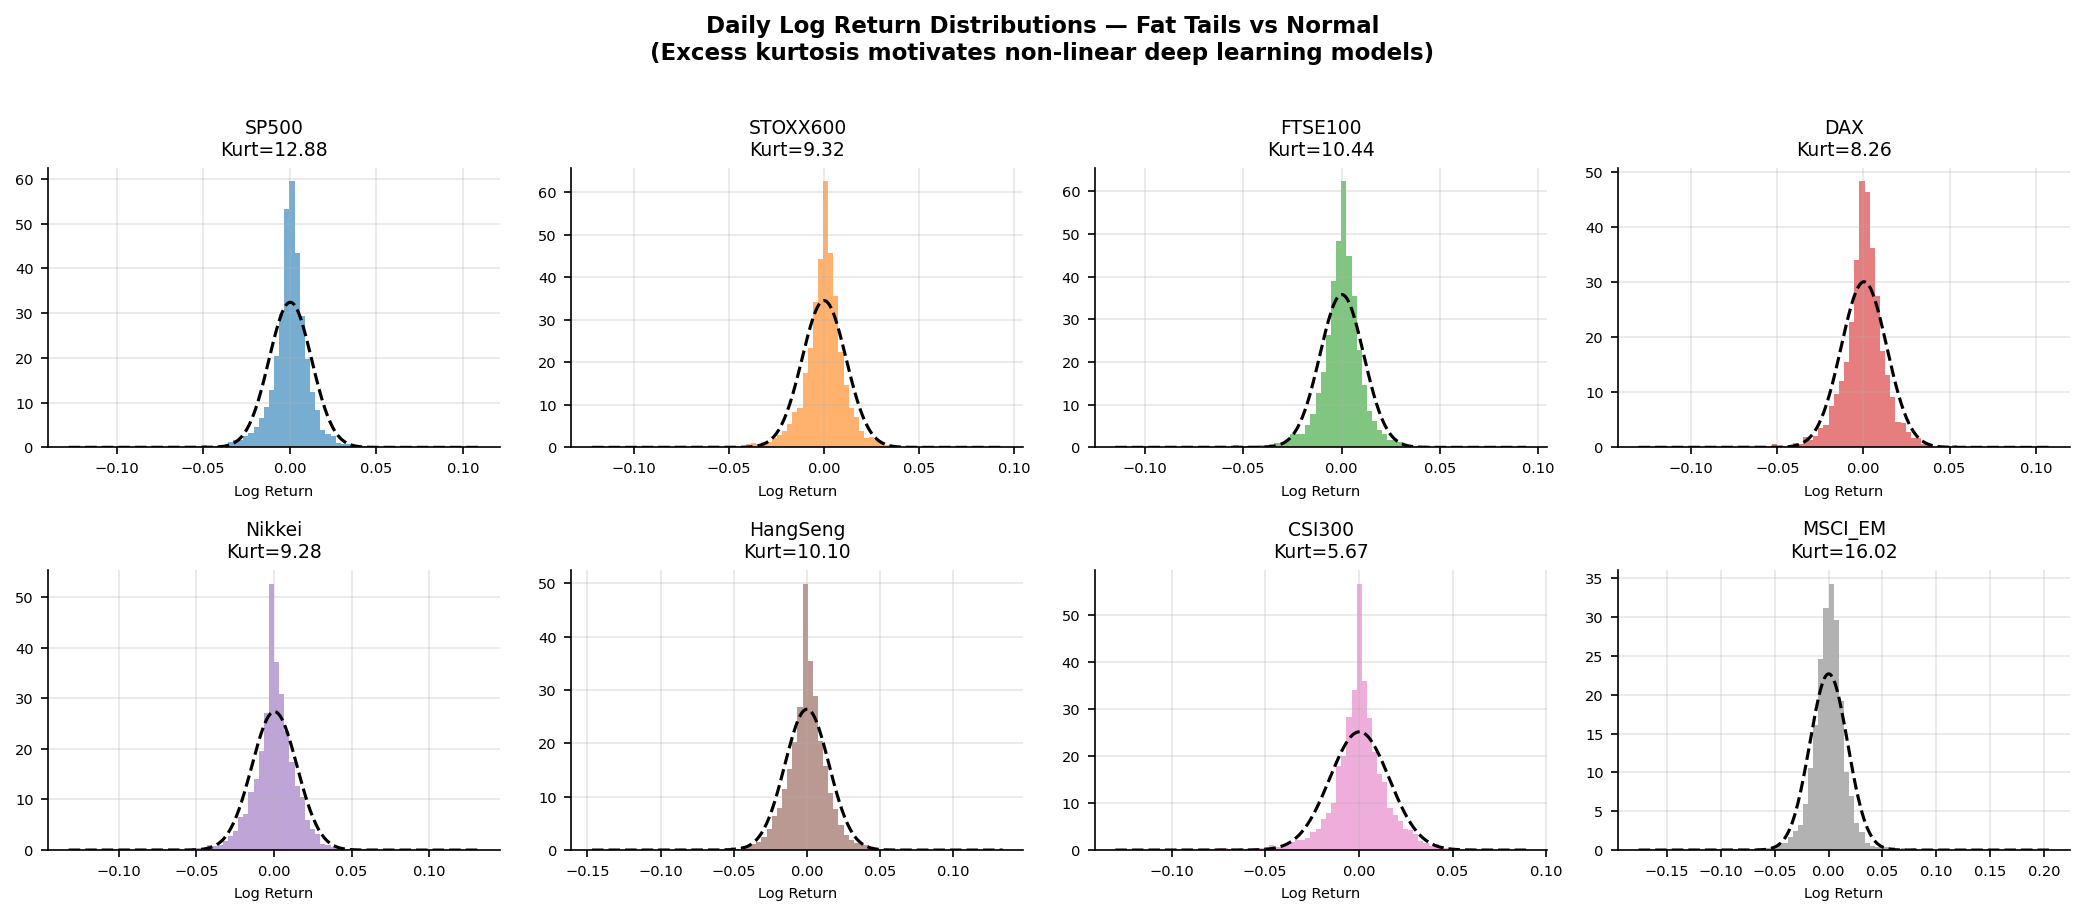

In [4]:
plot_return_distributions(returns_df)

---
## 4  Fig 3 · Correlation Heatmaps: Calm vs War

**Attention**: Warmer colours (higher correlations) in the war panel → markets move together more during conflict → risk contagion / spillover.

c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\src\eda.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig3_correlation_heatmaps.png


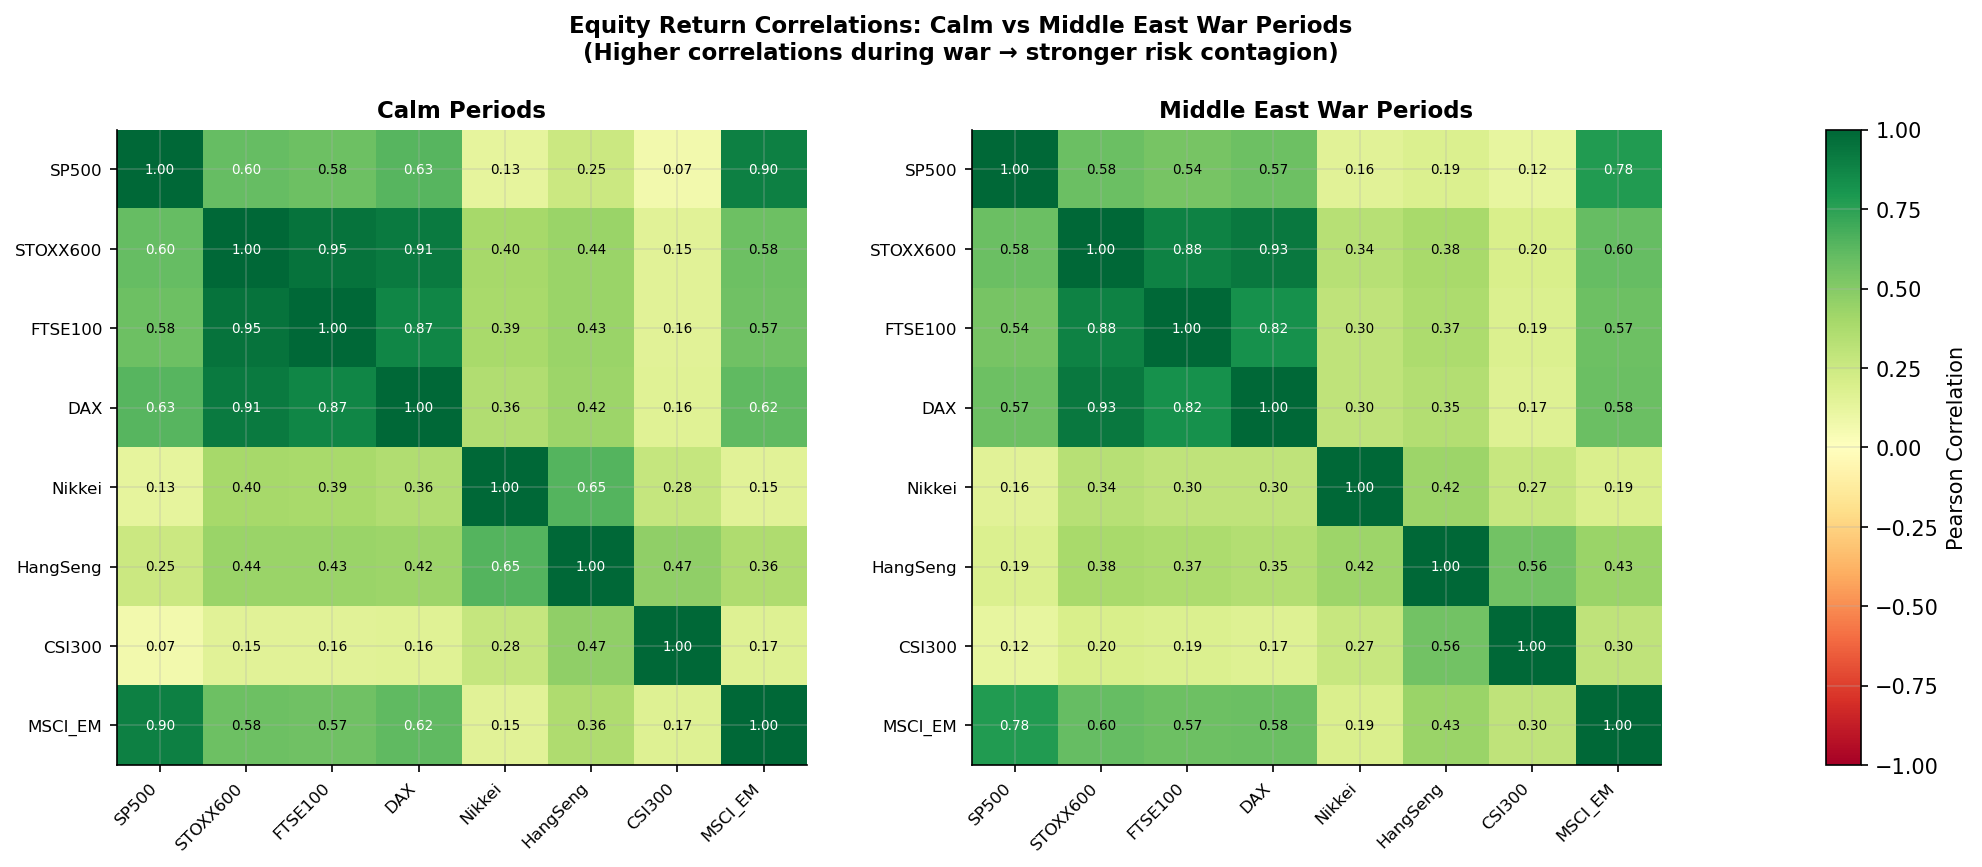

In [5]:
plot_correlation_heatmaps(returns_df, war_dummy)

---
## 5  Fig 4 · Event Study: Cumulative Returns Around War Start

**Attention**: Market drawdowns in the first ~20 trading days after event start.  
Compare Middle East events vs Russia-Ukraine in terms of transmission speed and depth.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig4_event_windows.png


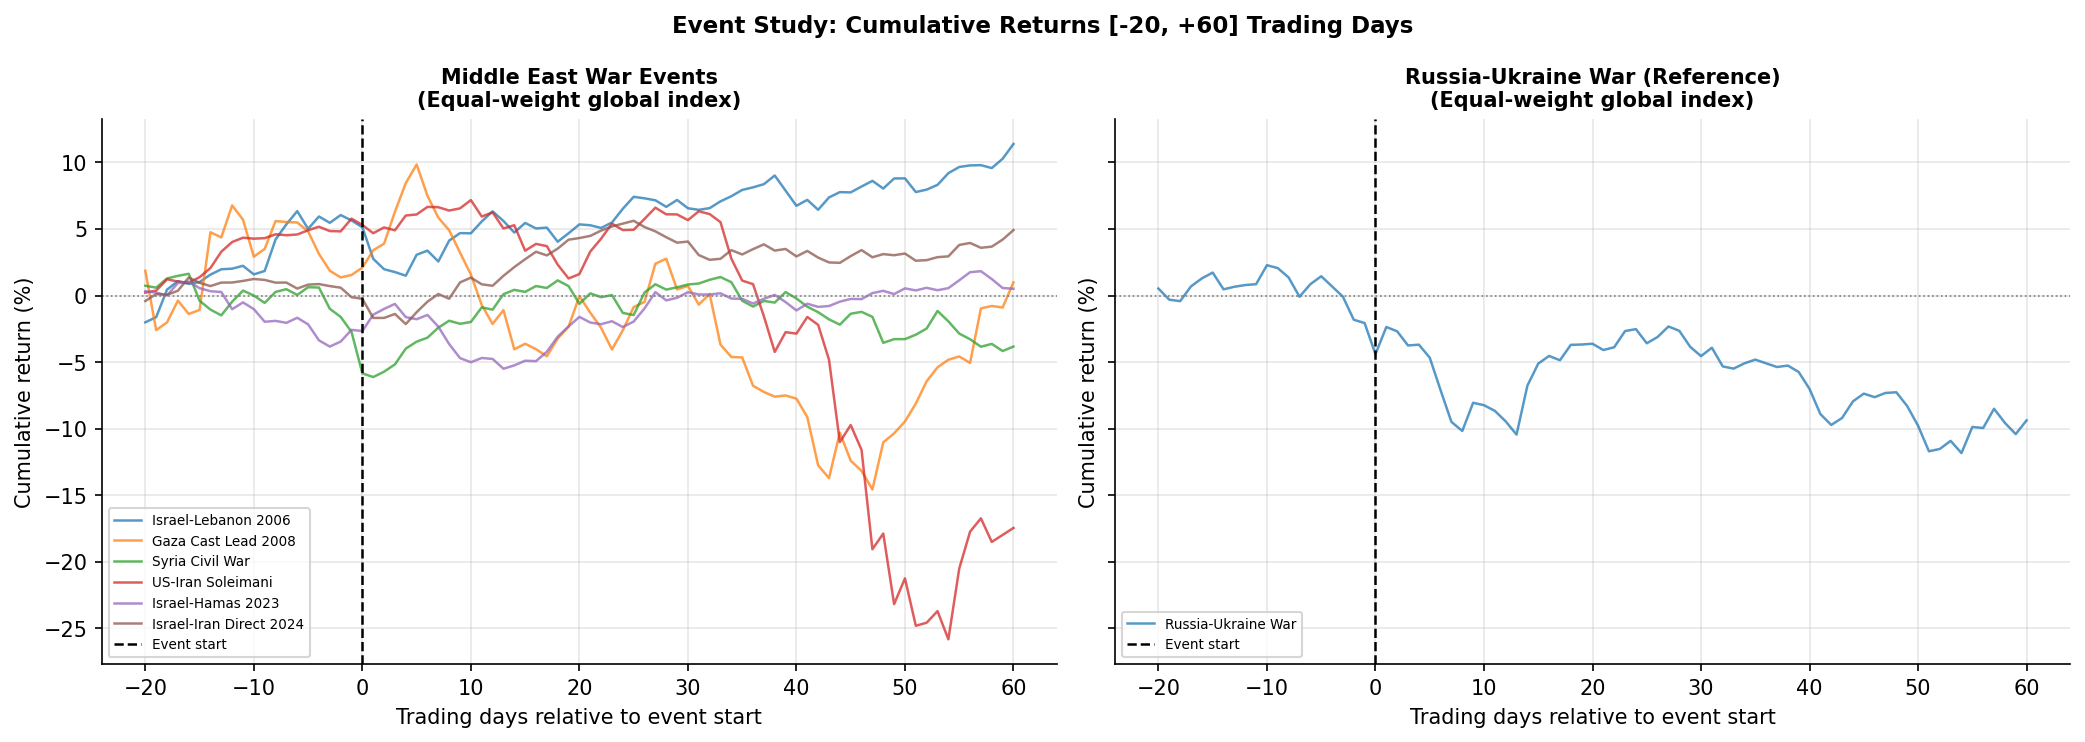

In [6]:
plot_event_windows(returns_df, events, pre=20, post=60)

---
## 6  Fig 5 · Oil / Gold / VIX Linkage During War Periods

**Attention**: Oil and VIX spikes during Middle East conflicts.  
The **anomalous gold decline** during Israel-Iran 2024 (the original research motivation) should be visible in the gold panel.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig5_macro_war_linkage.png


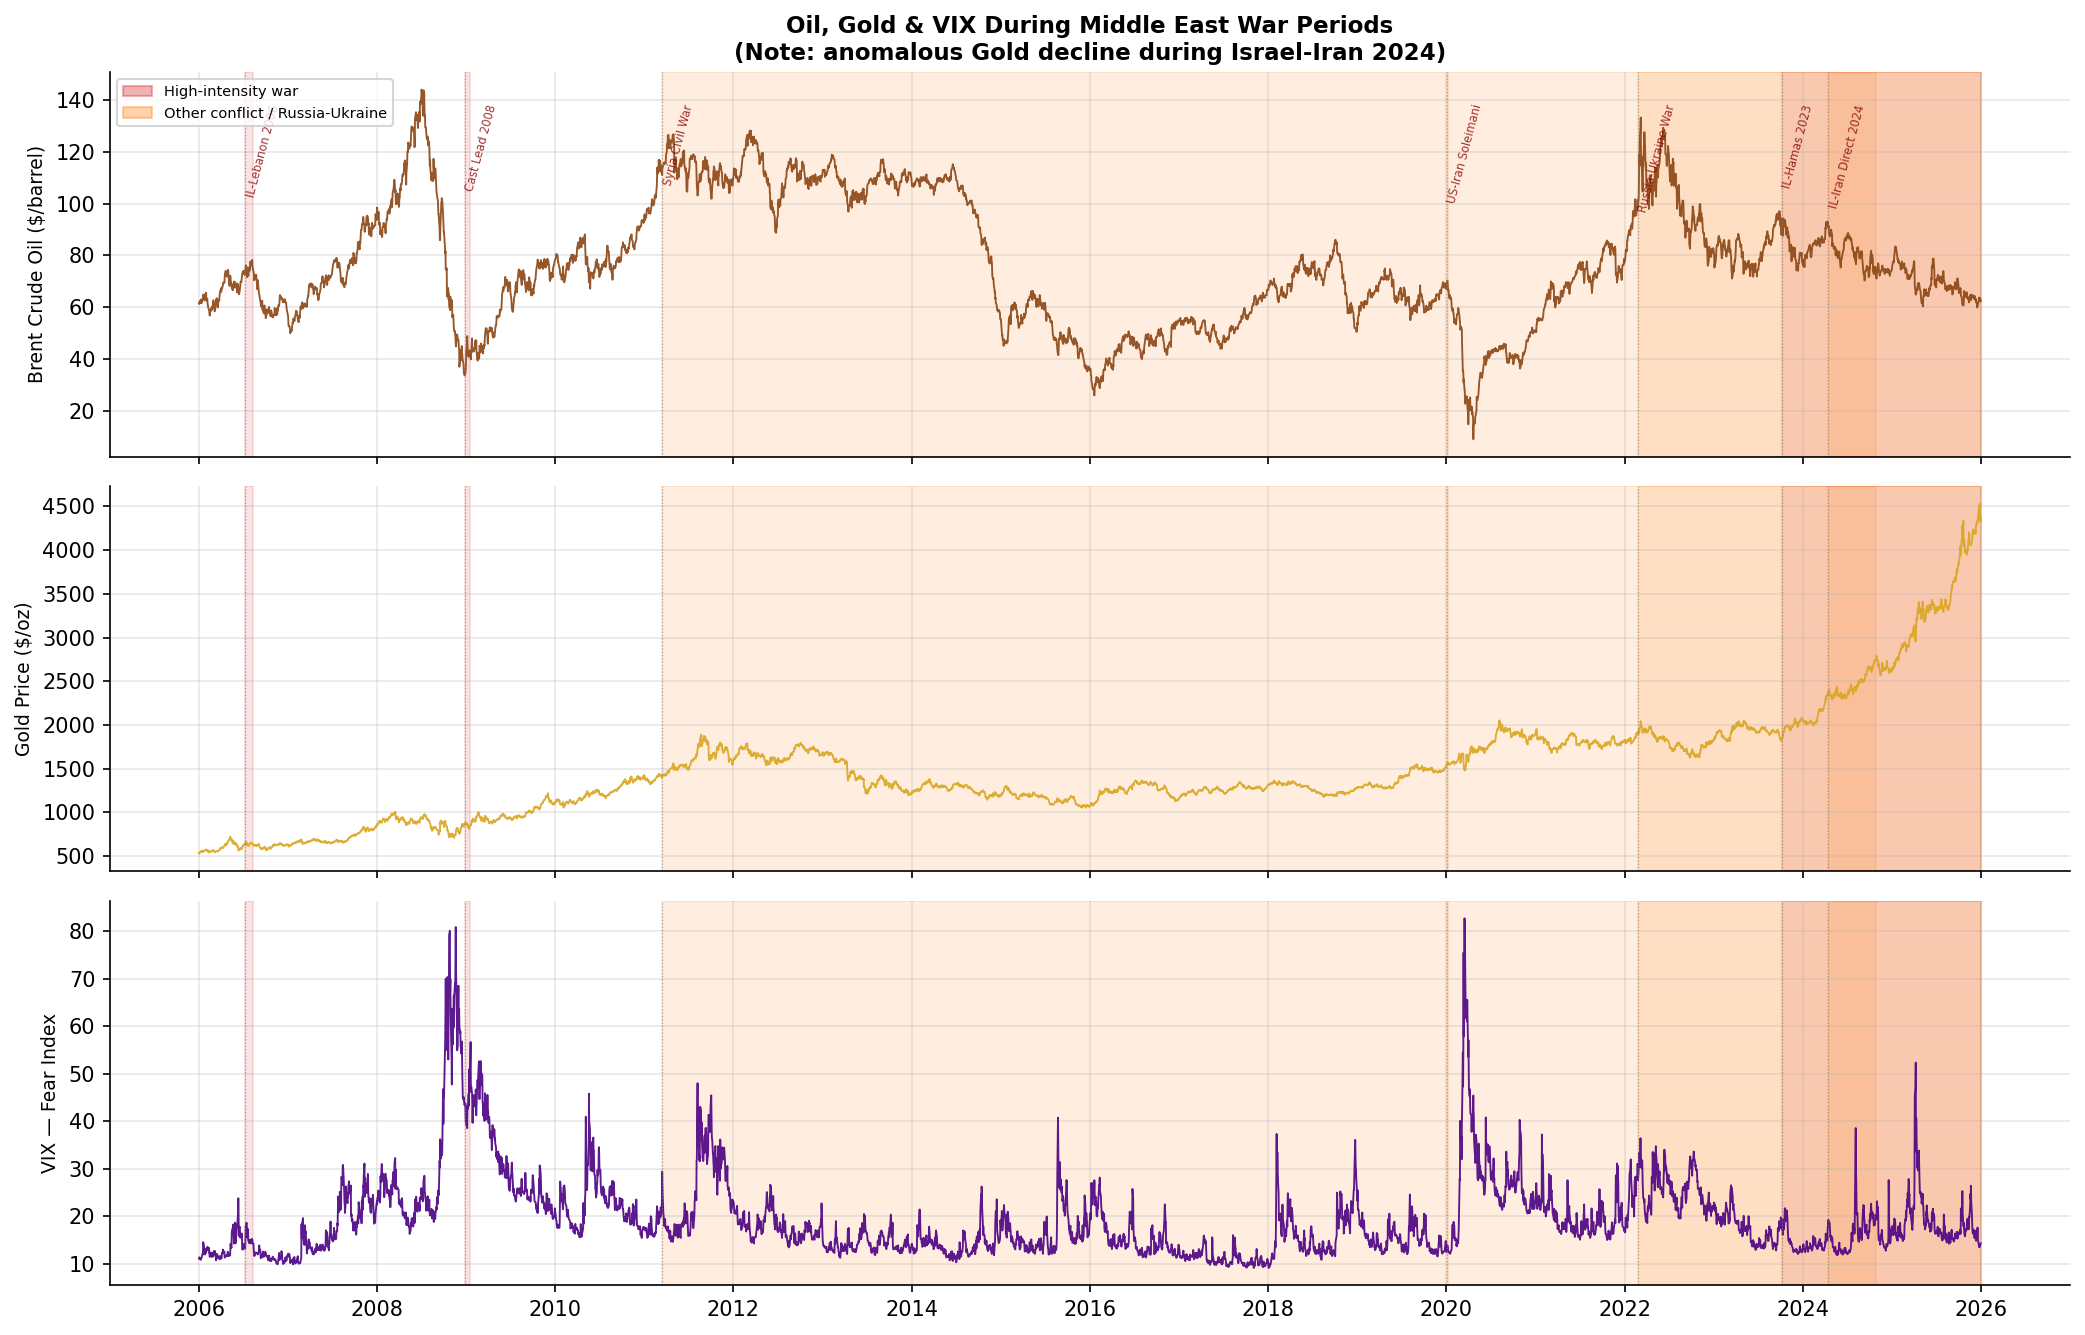

In [7]:
plot_macro_war_linkage(combined, events, end_date=END)

---
## 7  Table 1 · ADF Stationarity Tests

**Attention**: VAR requires stationary inputs. If any series is non-stationary (p > 0.05), it must be first-differenced before modelling.

In [8]:
adf_results = run_adf_tests(vol_df)


[ADF Test Results — Volatility Series]
          ADF Statistic  p-value  1% Critical  5% Critical Stationary?
Series                                                                
SP500           -6.4395   0.0000      -3.4317      -2.8621       ✅ Yes
STOXX600        -6.3112   0.0000      -3.4317      -2.8621       ✅ Yes
FTSE100         -6.3738   0.0000      -3.4317      -2.8621       ✅ Yes
DAX             -6.3643   0.0000      -3.4317      -2.8621       ✅ Yes
Nikkei          -7.2082   0.0000      -3.4317      -2.8621       ✅ Yes
HangSeng        -5.7816   0.0000      -3.4317      -2.8621       ✅ Yes
CSI300          -4.3328   0.0004      -3.4320      -2.8623       ✅ Yes
MSCI_EM         -6.1348   0.0000      -3.4317      -2.8621       ✅ Yes

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\tables\table_adf_tests.xlsx


---
## 8  Table 2 · War vs Calm — Crisis-Controlled Four-Regime Analysis

### Why four regimes?

The naive two-regime comparison (war=1 vs war=0) showed war-period volatility **lower** than calm-period volatility — a counter-intuitive result. The cause: GFC (Sep 2008 – Jun 2009) and COVID (Feb – Sep 2020) both fell in the 'calm' window (mideast_war=0 for most of their duration), inflating the calm-period baseline.

The four-regime decomposition isolates each effect cleanly:

| Regime | Definition | Purpose |
|--------|-----------|----------|
| **A: Pure Calm** | mideast_war=0, any_crisis=0 | Baseline |
| **B: War Only** | mideast_war=1, any_crisis=0 | Clean war effect |
| **C: Crisis Only** | mideast_war=0, any_crisis=1 | Clean crisis effect |
| **D: War+Crisis** | mideast_war=1, any_crisis=1 | Overlap
 |

**Key results to report**:
- **B/A ratio**: does war raise volatility above the pure-calm baseline?
- **C/A ratio**: how much larger is the crisis effect vs the war effect?
- **t-stat (B vs A)**: is the war effect statistically significant after crisis control?

In [9]:
summary = war_vs_calm_stats(vol_df, war_dummy)


[War vs Calm Volatility — Crisis-Controlled Summary]
  Regime A = Pure calm (no war, no crisis)
  Regime B = War only  (no GFC/COVID overlap)
  Regime C = Crisis only (GFC + COVID, no ME war)
  Regime D = War + Crisis overlap

          A: Pure Calm Mean  B: War-Only Mean  C: Crisis-Only Mean  D: War+Crisis Mean  High-Int Mean  B/A Ratio  C/A Ratio  t-stat (B vs A)  p-value Significant?
Market                                                                                                                                                            
SP500                0.1531            0.1386               0.4620              0.3293         0.1431      0.905      3.018           -6.429   0.0000            ✅
STOXX600             0.1636            0.1383               0.3919              0.2841         0.1174      0.845      2.395          -10.959   0.0000            ✅
FTSE100              0.1629            0.1289               0.3927              0.2969         0.1055      0.791      2.

---
## 9  Fig 5b · Crisis Decomposition Bar Chart

Visualises the four-regime mean volatilities side by side for each market.

**Attention**:
- Bar **C** (orange/crisis) >> Bar **A** (blue/calm) → GFC/COVID are the dominant vol driver; annotated as C/A ratio
- Bar **B** (red/war) > Bar **A** (blue/calm) → war effect exists after crisis control; annotated as B/A ratio
- This figure directly addresses the research design question: the war effect is real but modest compared to systemic crises — which is itself a finding (indirect/non-linear transmission channels)

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig5b_crisis_decomposition.png


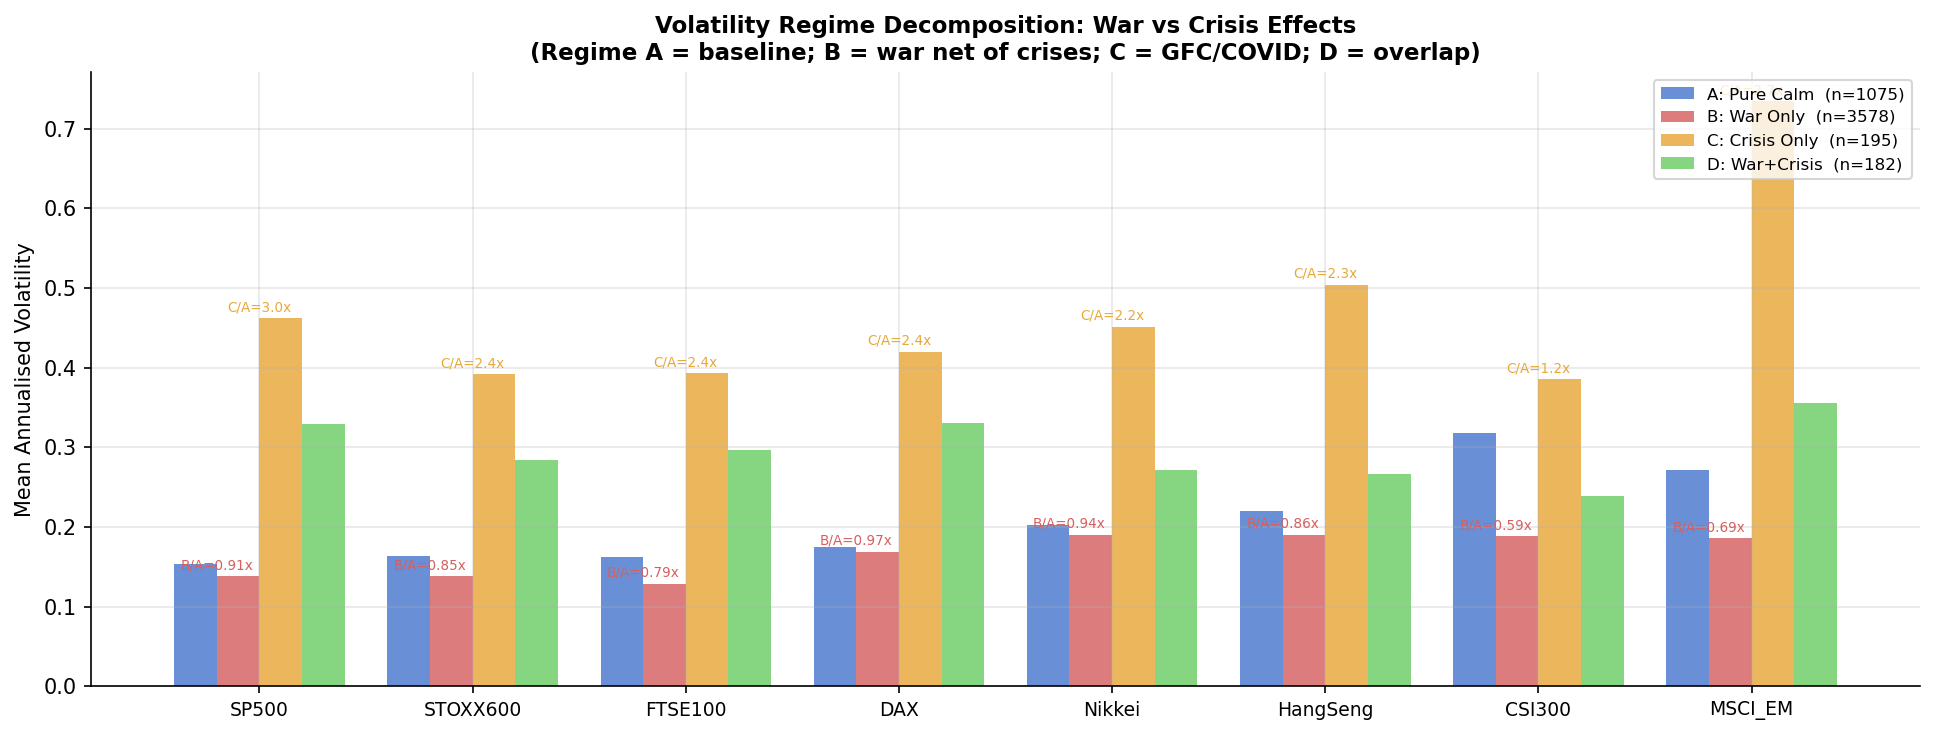

In [10]:
plot_crisis_decomposition(vol_df, war_dummy)

---
## 10  EDA Summary

The EDA cares "Do Middle East wars leave a measurable fingerprint on global markets, and through what channels? The answer is yes, but not in the ways the standard narrative would suggest.

Two findings are clean and unambiguous. All eight return series show excess kurtosis between 5.67 and 16.02, well above the normal benchmark of 3, which invalidates the Gaussian assumption in linear VAR and justifies using LSTM and GRU. All eight volatility series are stationary at the 1% level, so no differencing is needed before modelling.

The remaining findings require more careful interpretation. War-only volatility (Regime B) is actually lower than the pure-calm baseline (Regime A) in every market, with B/A ratios from 0.59 to 0.97. This is not because wars are calming; it is because Regime A itself contains the 2015 oil crash, the 2018 trade war, and the 2022 rate hiking cycle, all of which inflate the baseline without being flagged as a crisis. GFC and COVID, by contrast, produce volatility 1.2 to 3.0 times higher than that already-elevated baseline, confirming they operate on a different scale entirely. Similarly, war-period correlations appear lower than calm-period correlations in Fig 3, which reflects the fact that the war dummy spans over a decade of varied macroeconomic environments rather than isolating the short-lived contagion visible at event onset in Fig 4. The gold chart is dominated by a secular uptrend from 500 to 4,500 dollars per ounce, which makes the 2024 anomaly invisible at the daily price level.

For the modelling stage, three things follow directly from this. Crisis dummies for GFC and COVID must be included in the VARX specification or the war coefficients will be biased. The Soleimani event should be treated with caution since its post-event window is contaminated by COVID. And the gold analysis should use log returns or z-scored deviations rather than price levels to surface the anomaly the original hypothesis describes. The heterogeneity across events and market pairs is itself evidence that fixed-coefficient VAR will underfit, which is precisely where LSTM and GRU have an advantage.

**Next** → `03_spillover_index.ipynb` to build the Diebold-Yilmaz spillover index